# Deepfake Detection
This notebook goes into different models and methods for detecting Deepfakes. It starts out with loaidng in all the files, and creating the dataset and dataloaders need to run the ResNet18 model, EfficientNet-B4 model and the ViT model to see the difference in their ability to identify deepfakes.

In [1]:
import numpy as np 
import pandas as pd 
import os

BASE_PATH = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23'
FAKE_PATHS = ['Face2Face', 'Deepfakes', 'NeuralTextures', 'FaceShifter', 'FaceSwap', 'DeepFakeDetection']
CSV_PATHS = ['csv']
ORIGINAL_PATHS = ['original']

original_video_files = []
fake_video_files = []

labels = {
    'original':0,
    'Face2Face':1,
    'Deepfakes':1,
    'NeuralTextures':1,
    'FaceShifter':1,
    'FaceSwap':1,
    'DeepFakeDetection':1,
}

for fake_path in FAKE_PATHS:
    print(fake_path)
    print(BASE_PATH + fake_path)
    for dirname, _, filenames in os.walk(BASE_PATH + '/' + fake_path):
        print(f"{fake_path}: length: {len(filenames)}")

Face2Face
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23Face2Face
Face2Face: length: 1000
Deepfakes
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23Deepfakes
Deepfakes: length: 1000
NeuralTextures
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23NeuralTextures
NeuralTextures: length: 1000
FaceShifter
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23FaceShifter
FaceShifter: length: 1000
FaceSwap
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23FaceSwap
FaceSwap: length: 1000
DeepFakeDetection
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23DeepFakeDetection
DeepFakeDetection: length: 1000


In [2]:
# Frame Extraction Method
import cv2
import os
def extract_images(video_path, max_frames = 10):
    vid = cv2.VideoCapture(video_path)
    total = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))
    ret_frames = []
    if total==0:
        vid.release()
        return ret_frames
    frame_index = 0
    indices = np.linspace(0, total - 1, num=max_frames, endpoint=True, retstep=False, dtype=int)
    while vid.isOpened():
        ret, frame = vid.read()
        if not ret:
            break
        if frame_index in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ret_frames.append(frame)
        frame_index=frame_index+1
    vid.release()
    return ret_frames

In [3]:
#Actually Getting All the Frames
SAVE_PATH = '/kaggle/working/frames'
os.makedirs(SAVE_PATH, exist_ok=True)
all_frames = []
all_labels = []
all_categories = []

total_existing = sum(
    len(files) for _, _, files in os.walk(SAVE_PATH)
)
if total_existing>100:
    for category, label in labels.items():
        cat_path = os.path.join(SAVE_PATH, category)
        if not os.path.exists(cat_path):
            continue
        for filename in sorted(os.listdir(cat_path)):
            if filename.endswith('.png'):
                filepath = os.path.join(cat_path, filename)
                frame = cv2.imread(filepath)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (224, 224))
                all_frames.append(frame)
                all_labels.append(label)
                all_categories.append(category)
        print(f"{category}: loaded {len(os.listdir(cat_path))} frames")
else:
    for category, label in labels.items():
        save_cat_path = os.path.join(SAVE_PATH, category)
        os.makedirs(save_cat_path, exist_ok=True)
        active_dir = BASE_PATH + '/' + category
        curr_vids = []
        for dirname, _, filenames in os.walk(active_dir):
            for f in filenames:
                if f.endswith(('.mp4', '.avi', '.mov')):
                    curr_vids.append(os.path.join(active_dir, f))
        curr_vids = curr_vids[:100]
        print(f"{category}: found {len(curr_vids)} videos")
        for i, video_path in enumerate(curr_vids):
            if i % 10 == 0:
                print(f"  Processing video {i}/{len(curr_vids)}")
            frames = extract_images(video_path, max_frames=10)
            for j, frame in enumerate(frames):
                frame = cv2.resize(frame, (224, 224))
                save_file = os.path.join(save_cat_path, f'vid{i}_frame{j}.png')
                cv2.imwrite(save_file, frame)
                all_frames.append(frame)
                all_labels.append(label)
                all_categories.append(category)
print(f"\nTotal frames extracted: {len(all_frames)}")
print(f"Total labels: {len(all_labels)}")

original: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Processing video 40/100
  Processing video 50/100
  Processing video 60/100
  Processing video 70/100
  Processing video 80/100
  Processing video 90/100
Face2Face: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Processing video 40/100
  Processing video 50/100
  Processing video 60/100
  Processing video 70/100
  Processing video 80/100
  Processing video 90/100
Deepfakes: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Processing video 40/100
  Processing video 50/100
  Processing video 60/100
  Processing video 70/100
  Processing video 80/100
  Processing video 90/100
NeuralTextures: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Pr

In [4]:
#Splitting into Train, Test, Validate Sets
from sklearn.model_selection import train_test_split
all_frames = np.array(all_frames)
all_labels = np.array(all_labels)
all_types = np.array(all_categories)
X_train, X_temp, y_train, y_temp, types_train, types_temp = train_test_split(all_frames, all_labels, all_types, test_size=0.3, random_state=43, stratify=all_labels)
X_val, X_test, y_val, y_test, types_val, types_test = train_test_split(X_temp, y_temp, types_temp, test_size=0.5, random_state=43, stratify=y_temp)
print(f"X_Train length: {len(X_train)}")
print(f"X_val length: {len(X_val)}")
print(f"X_test length: {len(X_test)}")
print(f"Total Length: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Train - Real: {sum(y_train==0)}, Train - Fake: {sum(y_train==1)}")
print(f"Test - Real: {sum(y_test==0)}, Test - Fake: {sum(y_test==1)}")
print(f"Val - Real: {sum(y_val==0)}, Val - Fake: {sum(y_val==1)}")

X_Train length: 4900
X_val length: 1050
X_test length: 1050
Total Length: 7000
Train - Real: 700, Train - Fake: 4200
Test - Real: 150, Test - Fake: 900
Val - Real: 150, Val - Fake: 900


Train manipulation types:
Counter({np.str_('Deepfakes'): 717, np.str_('NeuralTextures'): 706, np.str_('FaceShifter'): 701, np.str_('original'): 700, np.str_('Face2Face'): 698, np.str_('FaceSwap'): 691, np.str_('DeepFakeDetection'): 687})

Val manipulation types:
Counter({np.str_('FaceShifter'): 155, np.str_('FaceSwap'): 155, np.str_('Face2Face'): 153, np.str_('original'): 150, np.str_('Deepfakes'): 149, np.str_('DeepFakeDetection'): 146, np.str_('NeuralTextures'): 142})

Test manipulation types:
Counter({np.str_('DeepFakeDetection'): 167, np.str_('FaceSwap'): 154, np.str_('NeuralTextures'): 152, np.str_('original'): 150, np.str_('Face2Face'): 149, np.str_('FaceShifter'): 144, np.str_('Deepfakes'): 134})


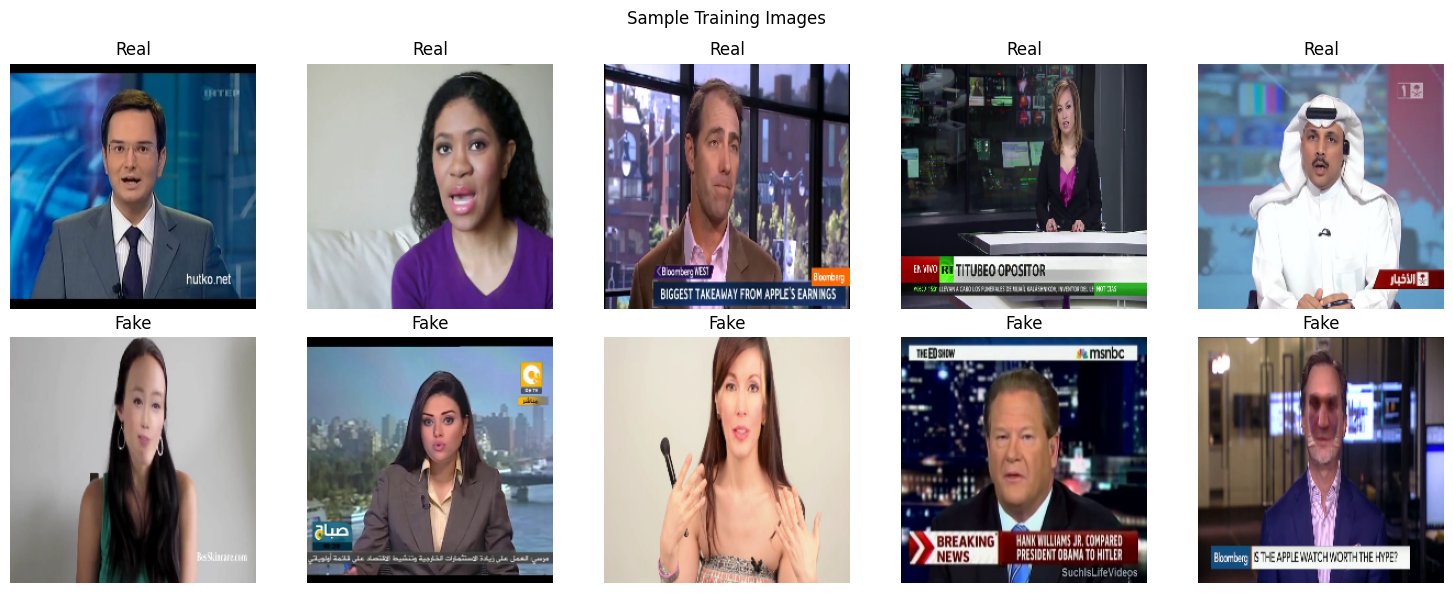

In [5]:
#Verifying Proper Splitting
import matplotlib.pyplot as plt
from collections import Counter

print("Train manipulation types:")
print(Counter(types_train))
print("\nVal manipulation types:")
print(Counter(types_val))
print("\nTest manipulation types:")
print(Counter(types_test))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images')

for i in range(5):
    real_idx = np.where(y_train == 0)[0][i]
    axes[0][i].imshow(X_train[real_idx])
    axes[0][i].set_title('Real')
    axes[0][i].axis('off')
    
    fake_idx = np.where(y_train == 1)[0][i]
    axes[1][i].imshow(X_train[fake_idx])
    axes[1][i].set_title(f'Fake')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

In [15]:
#Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class DeepfakeDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, image_idx):
        img = self.images[image_idx]
        if isinstance(img, str):
            img = Image.open(img).convert('RGB')
        else:
            img = Image.fromarray(img.astype(np.uint8))
        label = self.labels[image_idx]
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), value='random'), #new Addition to fix background attention and give more attention to actual deepfake features
    transforms.Normalize([0.485, 0.456, 0.406], 
                        [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                        [0.229, 0.224, 0.225])
])

In [16]:
train_dataset = DeepfakeDataset(X_train, y_train, train_transform)
test_dataset = DeepfakeDataset(X_test, y_test, test_transform)
validate_dataset = DeepfakeDataset(X_val, y_val, test_transform)

train_dataloader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, num_workers=2, shuffle=False)
validate_dataloader = DataLoader(validate_dataset, batch_size=32, num_workers=2, shuffle=False)

print(f"Train batches: {len(trainLoader)}")
print(f"Val batches:   {len(validateLoader)}")
print(f"Test batches:  {len(testLoader)}")

images, labels_batch = next(iter(trainLoader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels_batch.shape}")
print(f"Label values: {labels_batch[:5]}")

Train batches: 154
Val batches:   33
Test batches:  33
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label values: tensor([1, 1, 1, 1, 1])


In [17]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
#Base Model Training ResNet18
def get_resnet_baseline():
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    layers_to_freeze = ['layer1', 'layer2']
    for name, param in model.named_parameters():
        if any(layer in name for layer in layers_to_freeze): 
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #Train using GPU if available else CPU
print(f"Using device: {device}")

baseline_model = get_resnet_baseline()
baseline_model = baseline_model.to(device)
print("Baseline ResNet18 ready")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Baseline ResNet18 ready


In [18]:
#Training Loop Code
import torch.nn as nn
import torchvision.models as models
def train_model(model, train_dataloader, validate_dataloader, epochs=10, learning_rate=1e-4, model_name='model'):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4
    )
    #Fixing Class Imbalance by penalizing Fake Predictions more
    num_real = sum(y_train == 0)
    num_fake = sum(y_train == 1)
    total = len(y_train)

    weight_real = total / (2 * num_real)
    weight_fake = total / (2 * num_fake)
    class_weights = torch.FloatTensor([weight_real, weight_fake]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    history={'train_loss':[],'validate_loss':[], 'train_accuracy':[], 'validate_accuracy':[]}
    best_validate_accuracy = 0
    for epoch in range(epochs):
        #Training
        model.train()
        train_loss, train_correct = 0,0
        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
        #Validation
        model.eval()
        validate_loss, validate_correct = 0,0
        with torch.no_grad():
            for images, labels in validate_dataloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                validate_loss += loss.item()
                validate_correct += (outputs.argmax(1) == labels).sum().item()
        scheduler.step()

        train_accuracy = train_correct / len(train_dataloader.dataset)
        validate_accuracy = validate_correct / len(validate_dataloader.dataset)
        history['train_loss'].append(train_loss/len(train_dataloader))
        history['validate_loss'].append(validate_loss/len(validate_dataloader))
        history['train_accuracy'].append(train_accuracy)
        history['validate_accuracy'].append(validate_accuracy)
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Accuracy: {train_accuracy:.4f} | "
              f"Validate Accuracy: {validate_accuracy:.4f} | " 
              f"Train Loss: {train_loss/len(train_dataloader):.4f}")

        if validate_accuracy > best_validate_accuracy:
            best_validate_accuracy = validate_accuracy
            torch.save(model.state_dict(), f"/kaggle/working/{model_name}_best.pth")
            print(f"New Best Model saved ({validate_accuracy:.4f})")
    return model, history

In [19]:
baseline_model, baseline_history=train_model(
    baseline_model,
    train_dataloader,
    validate_dataloader,
    epochs=10,
    learning_rate=1e-4,
    model_name='resnet18_baseline'
)

Epoch 1/10 | Train Accuracy: 0.8169 | Validate Accuracy: 0.9733 | Train Loss: 0.3676
New Best Model saved (0.9733)
Epoch 2/10 | Train Accuracy: 0.9361 | Validate Accuracy: 0.9543 | Train Loss: 0.1763
Epoch 3/10 | Train Accuracy: 0.9502 | Validate Accuracy: 0.9610 | Train Loss: 0.1179
Epoch 4/10 | Train Accuracy: 0.9586 | Validate Accuracy: 0.9514 | Train Loss: 0.0985
Epoch 5/10 | Train Accuracy: 0.9586 | Validate Accuracy: 0.9505 | Train Loss: 0.0878
Epoch 6/10 | Train Accuracy: 0.9590 | Validate Accuracy: 0.9667 | Train Loss: 0.0756
Epoch 7/10 | Train Accuracy: 0.9684 | Validate Accuracy: 0.9771 | Train Loss: 0.0646
New Best Model saved (0.9771)
Epoch 8/10 | Train Accuracy: 0.9702 | Validate Accuracy: 0.9676 | Train Loss: 0.0677
Epoch 9/10 | Train Accuracy: 0.9706 | Validate Accuracy: 0.9657 | Train Loss: 0.0638
Epoch 10/10 | Train Accuracy: 0.9692 | Validate Accuracy: 0.9724 | Train Loss: 0.0631



 ---------ResNet18 Baseline Results---------
              precision    recall  f1-score   support

        Real       0.84      0.95      0.89       150
        Fake       0.99      0.97      0.98       900

    accuracy                           0.97      1050
   macro avg       0.92      0.96      0.94      1050
weighted avg       0.97      0.97      0.97      1050

ROC-AUC: 0.9965


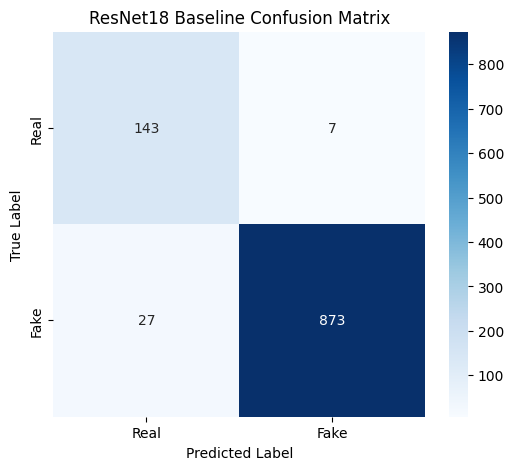

In [20]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
import seaborn as sns

def evaluate_model(model, test_dataloader, model_name='model'):
    model.eval() #Set model mode to Eval
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            predictions = outputs.argmax(1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    print(f"\n ---------{model_name} Results---------")
    print(classification_report(all_labels, all_predictions, target_names=['Real', 'Fake']))
    print(f"ROC-AUC: {roc_auc_score(all_labels, all_probabilities):.4f}")

    #Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.savefig(f"/kaggle/working/{model_name}_confusion_matrix.png")
    plt.show()

    return all_predictions, all_labels, all_probabilities

baseline_predictions, baseline_labels, baseline_probabilities = evaluate_model(baseline_model, test_dataloader, 'ResNet18 Baseline')


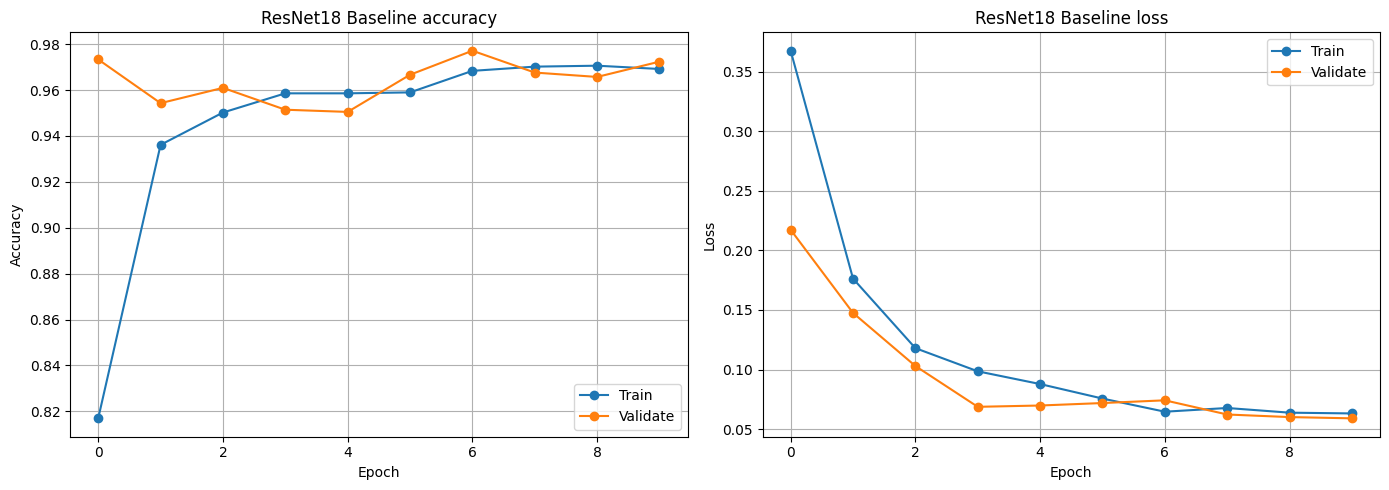

In [21]:
#Plotting the training history
def plot_training_history(history, model_name='Model'):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 5))

    ax1.plot(history['train_accuracy'], label='Train', marker='o')
    ax1.plot(history['validate_accuracy'], label='Validate', marker='o')
    ax1.set_title(f"{model_name} accuracy")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_loss'], label='Train', marker='o')
    ax2.plot(history['validate_loss'], label='Validate', marker='o')
    ax2.set_title(f"{model_name} loss")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_history.png')
    plt.show()

plot_training_history(baseline_history, 'ResNet18 Baseline')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 1/15 | Train Accuracy: 0.7141 | Validate Accuracy: 0.8695 | Train Loss: 0.6894
New Best Model saved (0.8695)
Epoch 2/15 | Train Accuracy: 0.8953 | Validate Accuracy: 0.9362 | Train Loss: 0.2871
New Best Model saved (0.9362)
Epoch 3/15 | Train Accuracy: 0.9265 | Validate Accuracy: 0.9543 | Train Loss: 0.1877
New Best Model saved (0.9543)
Epoch 4/15 | Train Accuracy: 0.9435 | Validate Accuracy: 0.9533 | Train Loss: 0.1519
Epoch 5/15 | Train Accuracy: 0.9506 | Validate Accuracy: 0.9543 | Train Loss: 0.1229
Epoch 6/15 | Train Accuracy: 0.9573 | Validate Accuracy: 0.9562 | Train Loss: 0.1115
New Best Model saved (0.9562)
Epoch 7/15 | Train Accuracy: 0.9531 | Validate Accuracy: 0.9571 | Train Loss: 0.1253
New Best Model saved (0.9571)
Epoch 8/15 | Train Accuracy: 0.9594 | Validate Accuracy: 0.9571 | Train Loss: 0.0980
Epoch 9/15 | Train Accuracy: 0.9616 | Validate Accuracy: 0.9533 | Train Loss: 0.0949
Epoch 10/15 | Train Accuracy: 0.9645 | Validate Accuracy: 0.9552 | Train Loss: 0.0947

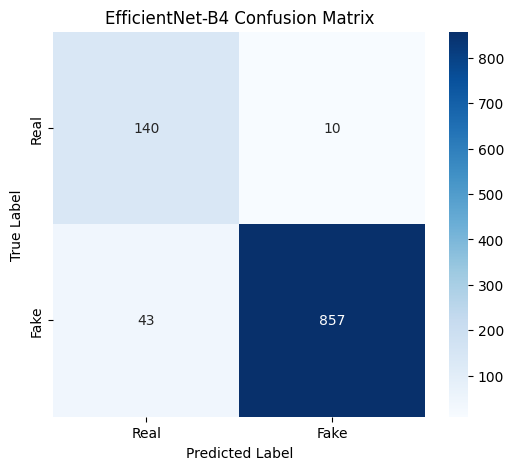

In [22]:
#Training EfficientNet-B4 Model
import timm

def get_efficientnet():
    model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=2)
    for param in model.parameters():
        param.requires_grad = False
    layers_to_freeze = ['blocks.3','blocks.4', 'blocks.5', 'blocks.6', 'conv_head', 'bn2', 'classifier']
    for name, param in model.named_parameters():
        if any(layer in name for layer in layers_to_freeze): 
            param.requires_grad = True
    return model

efficientnetb4_model = get_efficientnet().to(device)

efficientnetb4_model, efficientnetb4_history = train_model(
    efficientnetb4_model,
    train_dataloader,
    validate_dataloader,
    epochs=15,
    learning_rate=1e-4,
    model_name='efficientnet_b4'
)

efficientnetb4_predictions, efficientnetb4_labels, efficientnetb4_probabilities = evaluate_model(
    efficientnetb4_model, test_dataloader, 'EfficientNet-B4'
)

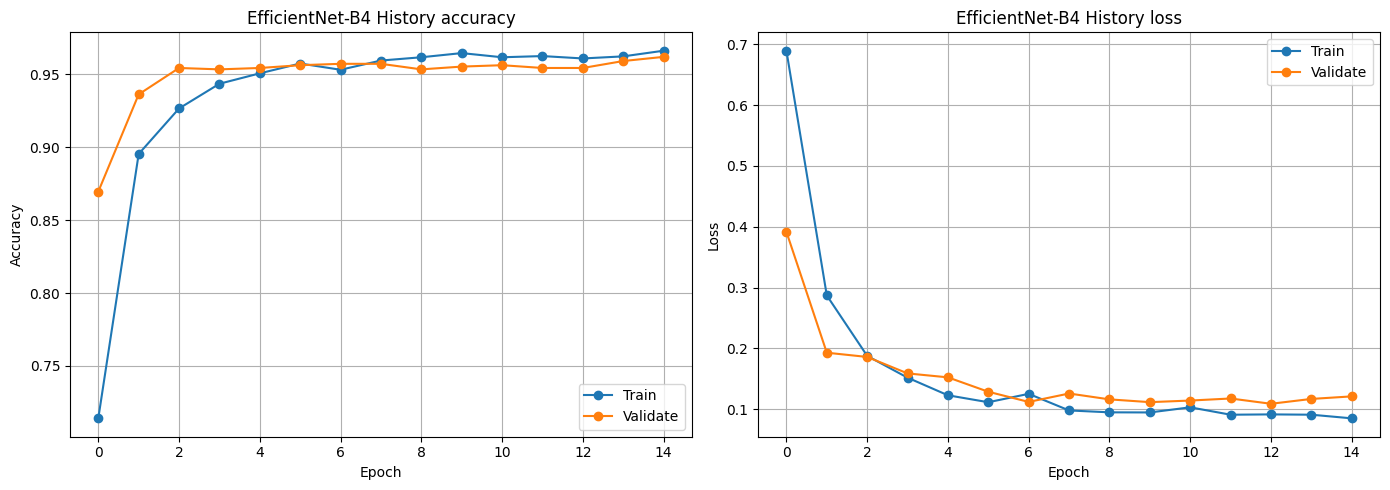

In [25]:
#Plotting Training History Data for EfficientNet-B4
plot_training_history(efficientnetb4_history, 'EfficientNet-B4 History')

Epoch 1/20 | Train Accuracy: 0.8473 | Validate Accuracy: 0.9333 | Train Loss: 0.3492
New Best Model saved (0.9333)
Epoch 2/20 | Train Accuracy: 0.9506 | Validate Accuracy: 0.9648 | Train Loss: 0.1192
New Best Model saved (0.9648)
Epoch 3/20 | Train Accuracy: 0.9551 | Validate Accuracy: 0.9438 | Train Loss: 0.0905
Epoch 4/20 | Train Accuracy: 0.9578 | Validate Accuracy: 0.9610 | Train Loss: 0.0680
Epoch 5/20 | Train Accuracy: 0.9612 | Validate Accuracy: 0.9524 | Train Loss: 0.0715
Epoch 6/20 | Train Accuracy: 0.9594 | Validate Accuracy: 0.9714 | Train Loss: 0.0674
New Best Model saved (0.9714)
Epoch 7/20 | Train Accuracy: 0.9622 | Validate Accuracy: 0.9657 | Train Loss: 0.0572
Epoch 8/20 | Train Accuracy: 0.9678 | Validate Accuracy: 0.9733 | Train Loss: 0.0540
New Best Model saved (0.9733)
Epoch 9/20 | Train Accuracy: 0.9714 | Validate Accuracy: 0.9657 | Train Loss: 0.0512
Epoch 10/20 | Train Accuracy: 0.9708 | Validate Accuracy: 0.9657 | Train Loss: 0.0491
Epoch 11/20 | Train Accuracy:

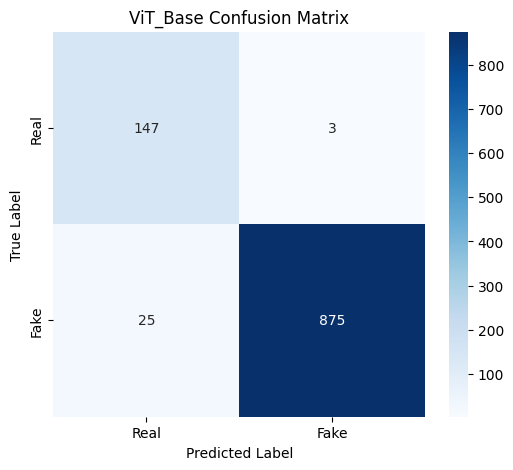

In [27]:
# Training ViT

def get_vit():
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
    for param in model.parameters():
        param.requires_grad = False

    layers_to_unfreeze = [
        'blocks.7',
        'blocks.8',
        'blocks.9',
        'blocks.10',
        'blocks.11',
        'norm',
        'head'
    ]
    for name, param in model.named_parameters():
        if any(layer in name for layer in layers_to_unfreeze):
            param.requires_grad = True
    return model

vit_model = get_vit().to(device)
vit_model, vit_history = train_model(
    vit_model,
    train_dataloader,
    validate_dataloader,
    epochs=20,
    learning_rate=5e-5,
    model_name='vit_base',
)

vit_predictions, vit_labels, vit_probabilities = evaluate_model(
    vit_model, test_dataloader, 'ViT_Base'
)

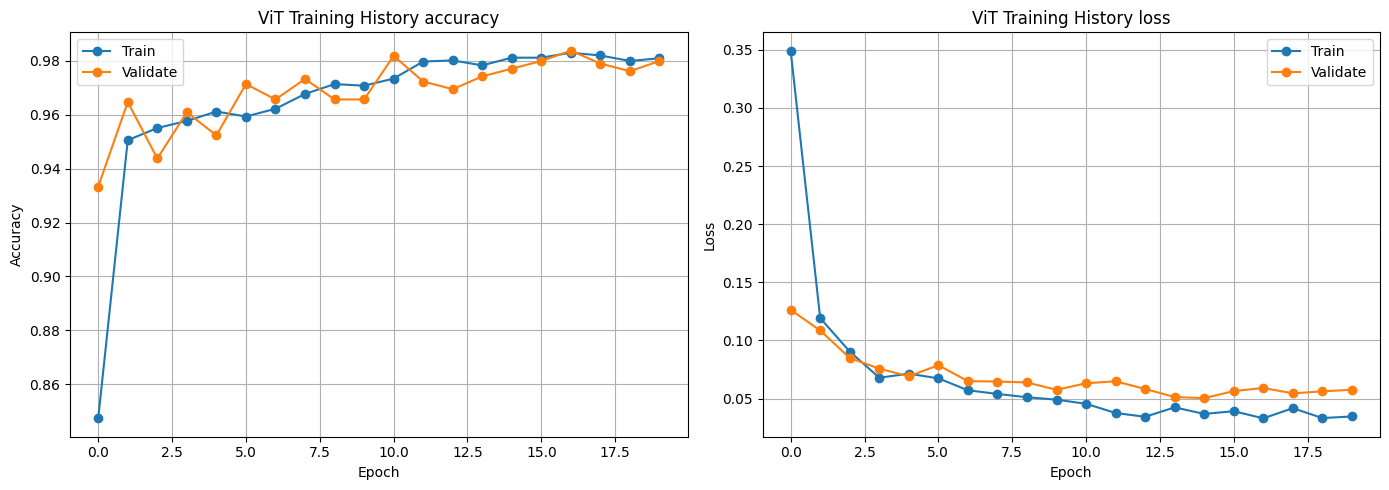

In [28]:
#Plotting Training History Data for ViT
plot_training_history(vit_history, 'ViT Training History')

In [29]:
!pip install grad-cam

Text(0.5, 1.0, 'ViT GradCAM')

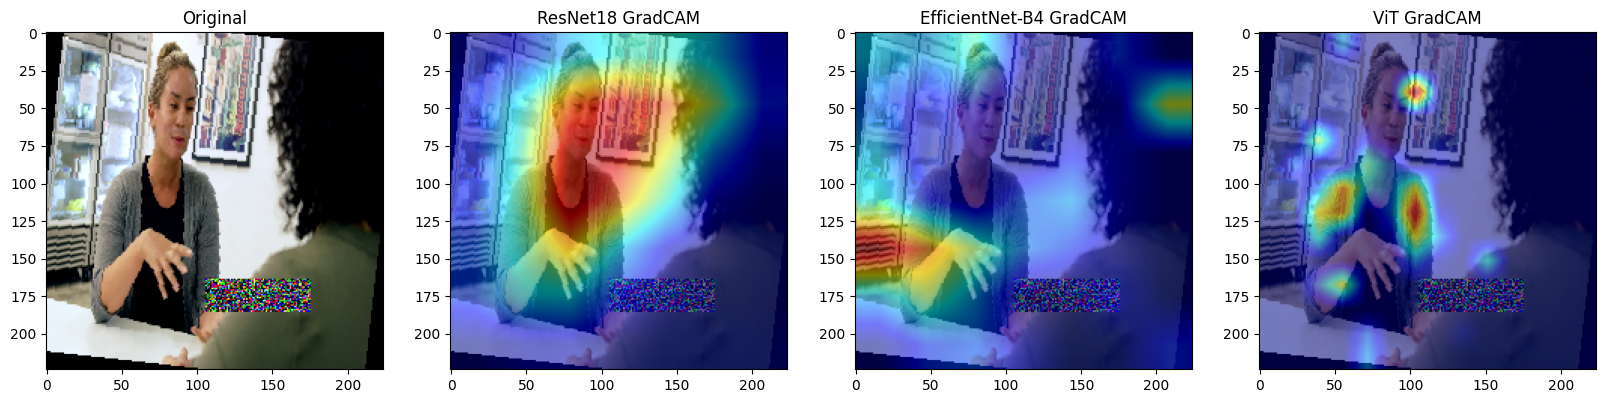

In [30]:
#Applying GradCAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def apply_gradcam(model, model_type, input_tensor, original_img):
    if model_type == 'resnet':
        target_layers = [model.layer4[-1]]
        reshape_transform = None
    elif model_type == 'efficientnet':
        target_layers = [model.conv_head]
        reshape_transform = None
    elif model_type == 'vit':
        target_layers = [model.blocks[-1].norm1]
        def reshape_transform(tensor, height = 14, width = 14):
            result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
            result = result.transpose(2,3).transpose(1,2)
            return result

    cam = GradCAM(model=model, target_layers = target_layers, reshape_transform = reshape_transform)
    grayscale_cam = cam(input_tensor = input_tensor, targets=None)[0,:]
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb = True)
    return visualization


idx = 10
img_tensor, label = train_dataset[idx]
input_tensor = img_tensor.unsqueeze(0).to(device)

rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
rgb_img = np.clip(rgb_img, 0, 1)

resnet18_cam = apply_gradcam(baseline_model, 'resnet', input_tensor, rgb_img)
efficientnet_cam = apply_gradcam(efficientnetb4_model, 'efficientnet', input_tensor, rgb_img)
vit_cam = apply_gradcam(vit_model, 'vit', input_tensor, rgb_img)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(rgb_img)
axes[0].set_title('Original')
axes[1].imshow(resnet18_cam)
axes[1].set_title('ResNet18 GradCAM')
axes[2].imshow(efficientnet_cam)
axes[2].set_title('EfficientNet-B4 GradCAM')
axes[3].imshow(vit_cam)
axes[3].set_title('ViT GradCAM')

In [ ]:
pip install umap-learn -q

In [ ]:
#UMAP and Clustering
